<a href="https://colab.research.google.com/github/devincriniti/DSC_110/blob/main/Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
###we important a new panda library as "pd" and a new matplot library calling in "plt"
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
### here we imported some data as "df"
df = pd.read_csv('https://raw.githubusercontent.com/osoliman/DSC110/refs/heads/main/Datasets/nhanes_final.csv')

In [5]:
### here were are doing a check of our data, looking at the first 5 rows
df.head()


,id,gender,age,race_ethnicity,education,bmi,height_cm,systolic_bp,has_diabetes,hba1c,fasting_glucose
0,130378.0,1.0,43.0,6.0,5.0,27.0,179.5,135.0,2.0,5.6,113.0
1,130379.0,1.0,66.0,3.0,5.0,33.5,174.2,121.0,2.0,5.6,99.0
2,130380.0,2.0,44.0,2.0,3.0,29.7,152.9,111.0,1.0,6.2,156.0
3,130381.0,2.0,5.0,7.0,NaN,23.8,120.1,NaN,2.0,NaN,NaN
4,130382.0,1.0,2.0,3.0,NaN,NaN,NaN,NaN,2.0,NaN,NaN


One numerical variable

<Axes: >

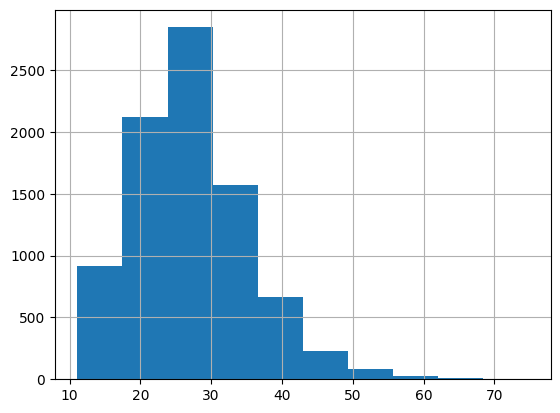

In [11]:
## here we built a graph/histogram with BMI on the x access and amount of people on the y axes
df['bmi'].hist()



### SINGLE CATEGORICAL VARIABLE


<Axes: xlabel='gender'>

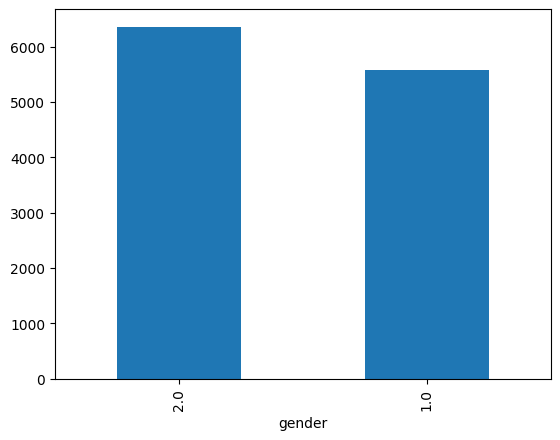

In [12]:
## here we created a bar graph of the data, with gender on the x axis and amount of people on the y axis - value counts counts each entry in that category of gender
df['gender'].value_counts().plot(kind='bar')

### two numerical variable

In [15]:
## here we are plotting two variables, fasting glucose and hba1c on a scatter plot, this is to look at their relationship, there is a direct relationship - both these variables are numeric
df.plot(x='fasting_glucose', y='hba1c', kind='scatter')

### TWO CATEGORICAL VARIABLES

<Axes: xlabel='gender'>

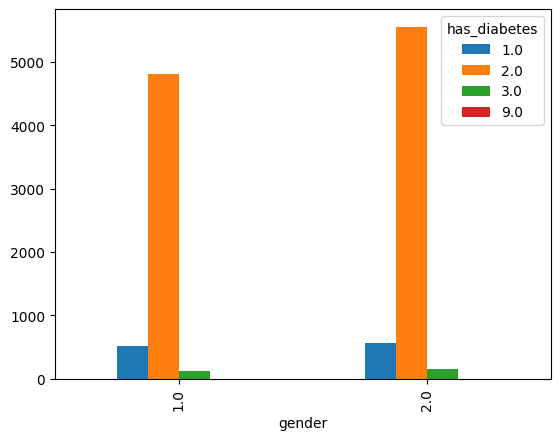

In [16]:
##here we are creating a bar graph that compares gender and wether or not they have diabetes - gender is on the x access, and amount of people is on the y access
pd.crosstab(df['gender'], df['has_diabetes']).plot(kind='bar')

### One numerical and one categorical

<Axes: title={'center': 'bmi'}, xlabel='gender'>

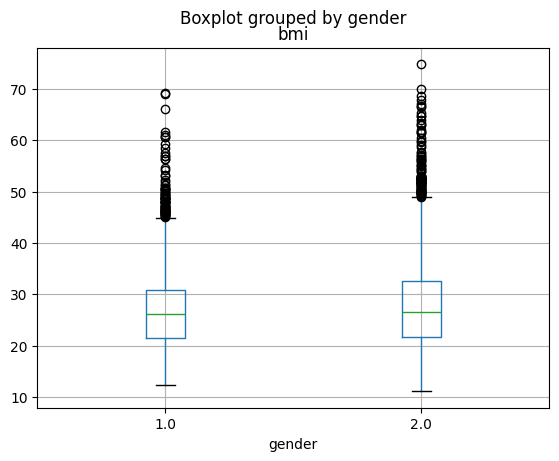

In [19]:
#here we are creating a boxplot graphy comparing bmi and gender, gender(categorical) is on the x axis and bmi(numerical) is on the y axis, the mean is showed by the green line in the box, and majority of the bmi values are within the box shown
df.boxplot(column='bmi', by='gender')

### Customizing the visualization

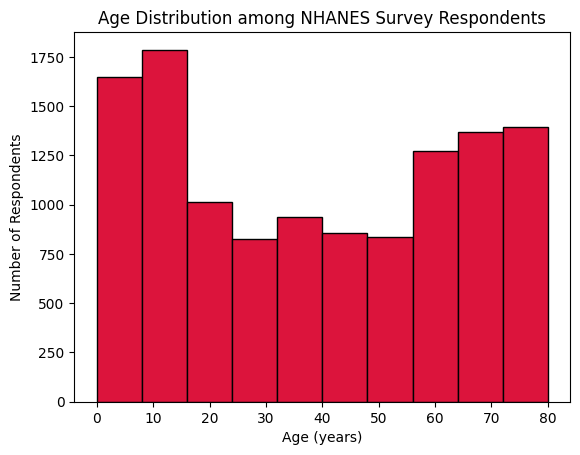

In [33]:
### here we added a title to the graph, and added labels to each axis, this way the graph makes sense even if it is taken out of context, we also took out the grid and changed the color to crimson and the outline of each bar to black
df['age'].hist(color='crimson', edgecolor='black')
plt.title('Age Distribution among NHANES Survey Respondents')
plt.xlabel('Age (years)')
plt.ylabel('Number of Respondents')
plt.grid(False)

##Seaborn Library

In [36]:
# here we importoted a seaborn library calling it "sns"
import seaborn as sns


Text(0, 0.5, 'BMI (kg/m²)')

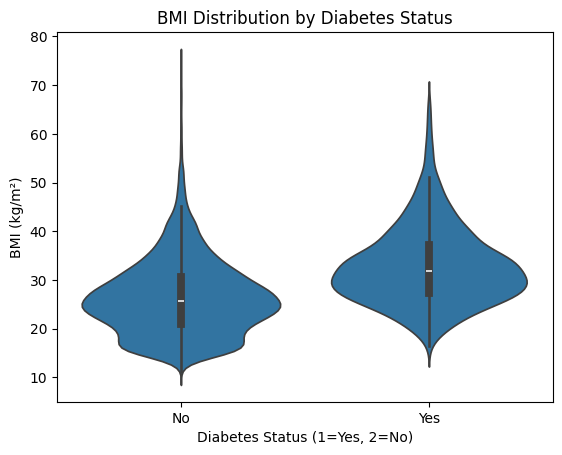

In [37]:
# Filter to only Yes (1) and No (2) diabetes responses - we are filtering out the 3 and 9 responses using isin command, and made a copy of it
df_diabetes = df[df['has_diabetes'].isin([1, 2])].copy()

# we assisgned yes to number 1 and no to number 2 - putting text to data making it more meanigful
diabetes_map={1:'Yes', 2:'No'}
df_diabetes['has_diabetes']=df_diabetes['has_diabetes'].map(diabetes_map)

# Create violin plot - we created a graph comparing diabetes and bmi, with graph and axis' labeled
sns.violinplot(data=df_diabetes, x='has_diabetes', y='bmi')
plt.title('BMI Distribution by Diabetes Status')
plt.xlabel('Diabetes Status (1=Yes, 2=No)')
plt.ylabel('BMI (kg/m²)')

Text(0.5, 1.0, 'Correlation Between Numeric Variables')

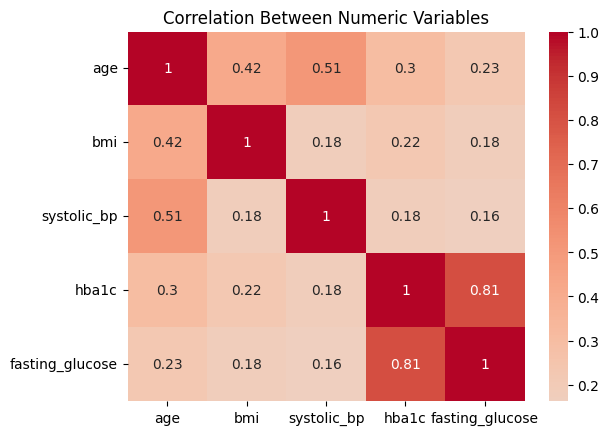

In [39]:
# Select only numeric columns - since we are selecting more than one field, we use two square brackets instead of one
numeric_cols = df[['age', 'bmi', 'systolic_bp', 'hba1c', 'fasting_glucose']].corr()

#we are creating a heatmap with the numeric columns, to show correlation between them - we see hba1c and fasting glucose have a strong correlation
sns.heatmap(numeric_cols, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Variables')


New package/library
TableOne

In [53]:
# here we are using package install package to install tableone
!pip install tableone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00


In [54]:
# here we are importing the newly installed tableone
import tableone

In [59]:
## here we are creating a table with all the variables with tableone, it gives us mean for the numerical values and we tell it to use median for age, since it is a non normal variable - we also have it show histograms for the data
tableone.TableOne(df, nonnormal='age', show_histograms=True)

Missing            Overall Histogram
n                                                    11933          
id, mean (SD)                         0  136344.0 (3444.9)  █▇▇▇▇▇▇█
gender, n (%)              1.0                 5575 (46.7)          
                           2.0                 6358 (53.3)          
age, median [Q1,Q3]                   0   37.0 [13.0,62.0]  █▇▃▄▄▄▆▆
race_ethnicity, n (%)      1.0                  1117 (9.4)          
                           2.0                 1373 (11.5)          
                           3.0                 6217 (52.1)          
                           4.0                 1597 (13.4)          
                           6.0                   681 (5.7)          
                           7.0                   948 (7.9)          
education, n (%)           1.0                   373 (3.1)          
                           2.0                   666 (5.6)          
                           3.0                 1749 (14.7)          
                           4.0                 2370 (19.9)          
                           5.0                 2625 (22.0)          
                           9.0                    11 (0.1)          
                           None                4139 (34.7)          
bmi, mean (SD)                     3462         27.2 (8.1)  ▅▆█▆▃▂▁▁
height_cm, mean (SD)               3434       159.7 (19.9)  ▁▁▁▁▃█▇▃
systolic_bp, mean (SD)             4416       119.3 (18.6)  ▃▆█▅▃▂▁▁
has_diabetes, n (%)        1.0                  1081 (9.1)          
                           2.0                10371 (86.9)          
                           3.0                   284 (2.4)          
                           9.0                     4 (0.0)          
                           None                  193 (1.6)          
hba1c, mean (SD)                   5218          5.7 (1.1)  ▄█▂▁▁▁▁▁
fasting_glucose, mean (SD)         8261       107.9 (32.5)  █▅▁▁▁▁▁▁